# AAPL Intraday Exploratory Data Analysis

Explore closing prices, five-minute returns, trading volume, and candle ranges. Data quality checks cover all downloaded symbols; detailed analysis focuses on AAPL. This notebook reads an existing Parquet snapshot and does not download or overwrite raw data.

Run from the repository root or its `notebooks/` directory. Generate `data/raw/stock-trend.parquet` using the ingestion workflow first. Results depend on the snapshot; a new rolling five-day download will change them.


## 1. Load Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd
file_path = project_root / "data" / "raw" / "stock-trend.parquet"
if not file_path.is_file():
    raise FileNotFoundError(
        "Raw snapshot missing. Run ingestion first and open this notebook "
        "from the repository root or notebooks directory."
    )
df_saved = pd.read_parquet(file_path)
if df_saved.empty:
    raise ValueError("The raw snapshot is empty.")
print(f"Shape: {df_saved.shape}")
print(f"Period: {df_saved.index.min()} to {df_saved.index.max()}")
print(f"Timezone: {df_saved.index.tz}")
df_saved.head()


Shape: (390, 25)
Period: 2026-09-03 09:30:00-04:00 to 2026-09-10 15:55:00-04:00
Timezone: America/New_York


Price                           Close              ...   Volume          
Ticker                           AAPL        AMZN  ...     MSFT      NVDA
Datetime                                           ...                   
2026-09-03 09:30:00-04:00  325.619995  257.859985  ...  1595900  10824587
2026-09-03 09:35:00-04:00  326.450012  258.755005  ...   543804   3599063
2026-09-03 09:40:00-04:00  326.484985  259.109985  ...   488526   3809094
2026-09-03 09:45:00-04:00  326.589996  258.559998  ...   537081   3181611
2026-09-03 09:50:00-04:00  326.269989  258.040009  ...   316071   2925404

[5 rows x 25 columns]

## 2. Data Quality Checks

In [2]:
price_cols = ["Close", "High", "Low", "Open"]
invalid_ohlc = (
    (df_saved["Low"] > df_saved["High"])
    | (df_saved["Open"] < df_saved["Low"])
    | (df_saved["Open"] > df_saved["High"])
    | (df_saved["Close"] < df_saved["Low"])
    | (df_saved["Close"] > df_saved["High"])
)
time_diffs = df_saved.index.to_series().diff()
gaps = time_diffs[
    (time_diffs > pd.Timedelta(minutes=5))
    & (time_diffs < pd.Timedelta(hours=15))
]
pd.Series({
    "Duplicate timestamps": int(df_saved.index.duplicated().sum()),
    "Chronologically sorted": df_saved.index.is_monotonic_increasing,
    "Missing cells": int(df_saved.isna().sum().sum()),
    "Non-numeric columns": int(sum(not pd.api.types.is_numeric_dtype(t) for t in df_saved.dtypes)),
    "Non-positive price cells": int((df_saved[price_cols] <= 0).sum().sum()),
    "Negative volume cells": int((df_saved["Volume"] < 0).sum().sum()),
    "Invalid OHLC timestamp-symbol pairs": int(invalid_ohlc.sum().sum()),
    "Gaps between 5 minutes and 15 hours": len(gaps),
}, name="Result").to_frame()


,Result
Duplicate timestamps,0
Chronologically sorted,True
Missing cells,0
Non-numeric columns,0
Non-positive price cells,0
Negative volume cells,0
Invalid OHLC timestamp-symbol pairs,0
Gaps between 5 minutes and 15 hours,0


The gap check is a preliminary heuristic, not a completeness test against an exchange calendar. Missing opening/closing candles or whole sessions may go undetected. A large observation is not automatically an error. No rows are automatically imputed or removed here.


## 3. Summary Statistics — AAPL

In [3]:
df_aapl = df_saved.xs("AAPL", axis=1, level="Ticker").copy()
df_aapl.describe()


Price,Close,High,Low,Open,Volume
count,390.000000,390.000000,390.000000,390.000000,3.900000e+02
mean,320.467067,320.842858,320.080815,320.457793,5.221533e+05
std,5.288528,5.258123,5.303316,5.285929,4.862627e+05
min,310.079987,311.309998,309.899994,310.059998,1.155410e+05
25%,316.022491,316.242493,315.760010,316.021240,2.405772e+05
50%,320.573853,321.044937,320.190002,320.588699,3.823005e+05
75%,325.032509,325.507507,324.332504,325.019997,6.000320e+05
max,330.464996,330.809998,330.045013,330.500000,4.639752e+06


## 4. Closing Prices

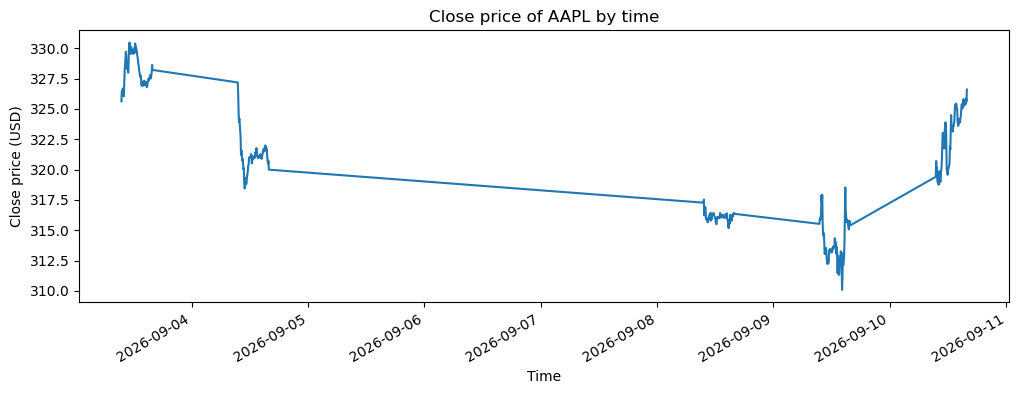

In [4]:
close_aapl = df_saved[("Close", "AAPL")]
close_aapl.plot(figsize=(12, 4))
plt.title("Close price of AAPL by time")
plt.xlabel("Time")
plt.ylabel("Close price (USD)")
plt.show()

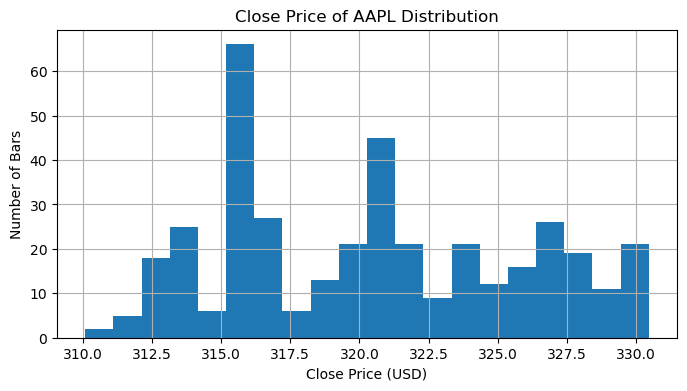

In [5]:
close_aapl.hist(bins=20, figsize=(8, 4))

plt.title("Close Price of AAPL Distribution")
plt.xlabel("Close Price (USD)")
plt.ylabel("Number of Bars")
plt.show()

## 5. Five-Minute Returns

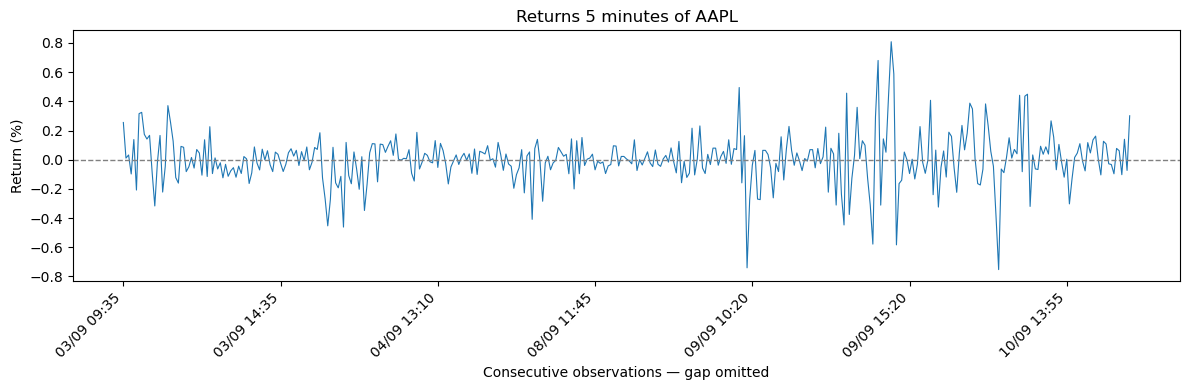

In [6]:
returns = close_aapl.pct_change(fill_method=None) * 100
is_5min = (
    close_aapl.index.to_series()
    .diff()
    .eq(pd.Timedelta(minutes=5))
    )
returns = returns.where(is_5min)

returns_plot = returns.dropna()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    range(len(returns_plot)),
    returns_plot.to_numpy(),
    linewidth=0.8,
)

positions = list(range(0, len(returns_plot), 60))
ax.set_xticks(positions)
ax.set_xticklabels(
    returns_plot.index[positions].strftime("%d/%m %H:%M"),
    rotation=45,
    ha="right",
)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Returns 5 minutes of AAPL")
ax.set_xlabel("Consecutive observations — gap omitted")
ax.set_ylabel("Return (%)")

plt.tight_layout()
plt.show()

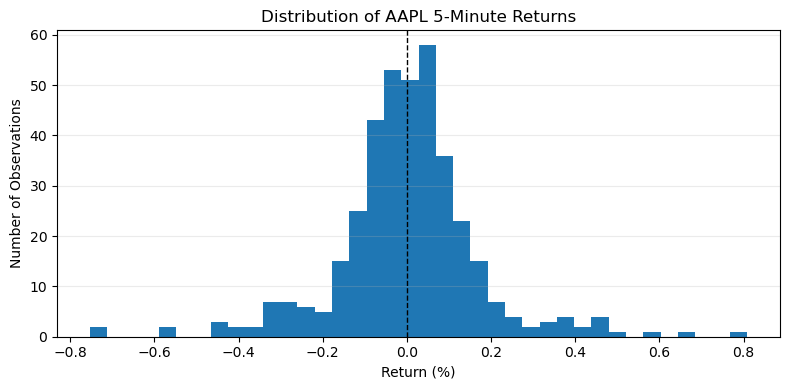

In [7]:
returns_plot.hist(bins="auto", figsize=(8, 4))

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of AAPL 5-Minute Returns")
plt.xlabel("Return (%)")
plt.ylabel("Number of Observations")
plt.grid(axis="x", visible=False)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

Returns are retained only when consecutive observations are exactly five minutes apart. The line chart compresses non-trading intervals and connects retained observations across sessions; horizontal spacing does not represent elapsed clock time.


## 6. Trading Volume

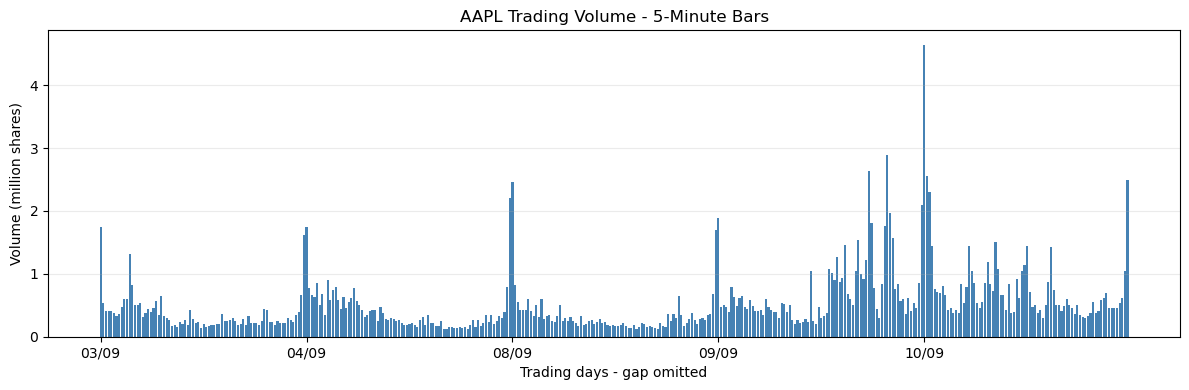

In [8]:
volume_aapl = df_saved[("Volume", "AAPL")]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    range(len(volume_aapl)),
    volume_aapl.to_numpy() / 1_000_000,
    color="steelblue",
    width=0.8
)

dates = volume_aapl.index.normalize()
positions = [
    i for i in range(len(dates))
    if i == 0 or dates[i] != dates[i - 1]
]

ax.set_xticks(positions)
ax.set_xticklabels(
    volume_aapl.index[positions].strftime("%d/%m"),
)

ax.set_title("AAPL Trading Volume - 5-Minute Bars")
ax.set_xlabel("Trading days - gap omitted")
ax.set_ylabel("Volume (million shares)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

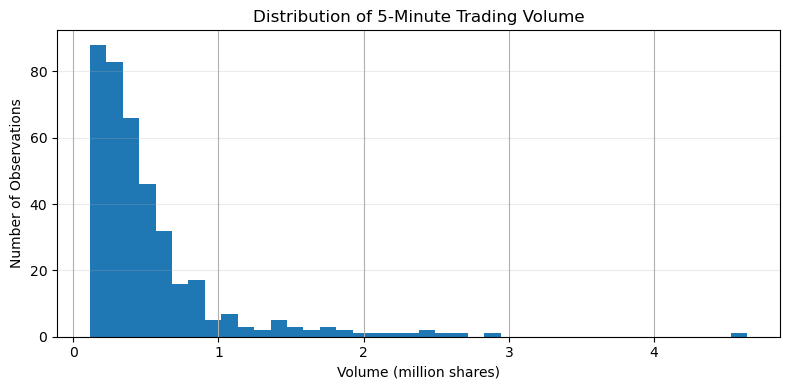

In [9]:
(volume_aapl / 1_000_000).hist(bins="auto", figsize=(8, 4))

plt.title("Distribution of 5-Minute Trading Volume")
plt.xlabel("Volume (million shares)")
plt.ylabel("Number of Observations")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Within-Candle Changes and Ranges

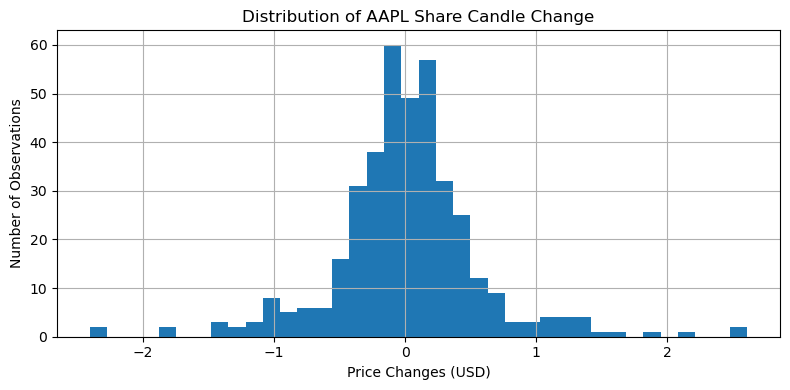

In [10]:
price_change_aapl = df_saved[("Close", "AAPL")] - df_saved[("Open", "AAPL")]

price_change_aapl.hist(bins="auto", figsize=(8, 4))
plt.title("Distribution of AAPL Share Candle Change")
plt.xlabel("Price Changes (USD)")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

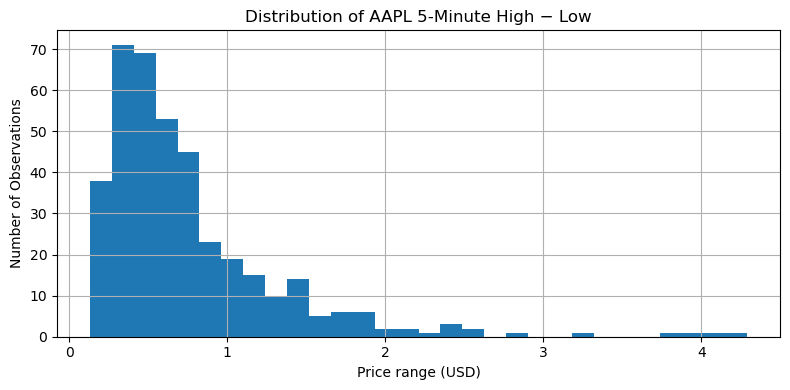

In [11]:
price_range_aapl = df_saved[("High", "AAPL")] - df_saved[("Low", "AAPL")]

price_range_aapl.hist(bins="auto", figsize=(8, 4))
plt.title("Distribution of AAPL 5-Minute High − Low")
plt.xlabel("Price range (USD)")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

## 8. Volume vs Absolute Returns

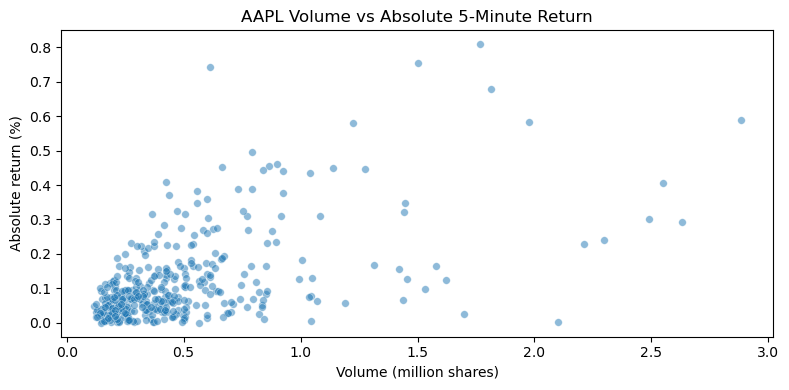

In [12]:
scatter_data = pd.concat(
    [
        (volume_aapl / 1_000_000).rename("volume_million"),
        returns.abs().rename("abs_return_pct"),
    ],
    axis=1,
).dropna()

plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=scatter_data,
    x="volume_million",
    y="abs_return_pct",
    alpha=0.5,
    s=30,
)

plt.title("AAPL Volume vs Absolute 5-Minute Return")
plt.xlabel("Volume (million shares)")
plt.ylabel("Absolute return (%)")
plt.tight_layout()
plt.show()

Each point pairs volume with the absolute five-minute return at the same timestamp. This explores movement magnitude, not whether price rises. High-volume observations are sparse, so any apparent relationship needs further validation and does not establish causation.


## 9. Findings and Limitations

The observations below describe the original snapshot (September 3–10, 2026) and must be revisited if the input changes.

- AAPL closing prices ranged from approximately $310.08 to $330.46. The mean ($320.47) was close to the median ($320.57), which alone does not establish symmetry.
- Five-minute returns were concentrated near zero, with most observations approximately between −0.2% and +0.2% and occasional larger movements in both directions.
- Volume was strongly right-skewed: most candles had fewer than one million shares traded, with a maximum around 4.6 million.
- Close minus Open clustered near zero. High minus Low measures a different property: the full candle range, which can be wide even when Open and Close are similar.
- The volume–absolute-return scatter is exploratory. Sparse high-volume observations limit conclusions, and no predictive relationship has been established.

Use the quality table above for the current snapshot's check results. Timestamp completeness remains unverified against an exchange trading calendar. Large movements should be inspected at their timestamps before considering removal.

This short sample supports workflow development rather than reliable model evaluation. Feature and target generation live in `src/features.py`; chronological splitting and model evaluation belong in `src/train.py`. Future prices must not enter model inputs.
